# 04 多设备并行、确定性与精度

引擎把路径分成固定大小的块（默认 8192 条），每个设备用 `lax.scan` 依次处理一段连续的块号，最后用 `psum` 汇总。
这个例子看几件和执行有关的事：

1. 在 CPU 上拆出虚拟设备后的扩展性；
2. 四种并行方式：`shard_map`（默认）、`auto`（GSPMD）、`pmap`（仅作对照）、`none`；
3. `deterministic_reduction`：结果与设备数逐位一致；
4. `float32` 路径；
5. 块数分桶，减少因为路径数变化而重新编译的次数；
6. GPU：同一份代码。

setup 里的 `dj.config.configure(num_cpu_devices=...)` 必须在任何 JAX 运算之前执行。下面的耗时取决于机器，只用来比较相对快慢。

In [1]:
import os

import dal_jax as dj

# Split the CPU into virtual devices so Monte Carlo blocks run in parallel.
# JAX only accepts this before its first operation, so keep it at the top.
dj.config.configure(num_cpu_devices=min(8, os.cpu_count() or 1))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from nbtools import AQUA, BLUE, MUTED, ORANGE, apply_style, label_end, show_table

try:
    import dal  # dal-python, only used for side-by-side comparisons
except ImportError:
    dal = None

apply_style()
print(f"jax {jax.__version__}: {len(jax.devices())} x {jax.devices()[0].platform} device(s); dal-python: {dal is not None}")

starting DAL with: 32 threads.
use AAD framework: AADET
starting initialization global data ...
finished initialization all the global information.
jax 0.11.2: 8 x cpu device(s); dal-python: True


In [2]:
import time

from dal_jax.script.lower import cspr

SPOT, VOL, RATE, DIV, STRIKE, BARRIER = 100.0, 0.15, 0.05, 0.03, 120.0, 150.0
model = dj.BlackScholes(spot=SPOT, vol=VOL, rate=RATE, div=DIV)


def call(params, scenario, ctx):
    return jnp.maximum(scenario.spot[-1] - params["script"]["STRIKE"], 0.0) / scenario.numeraire[-1]


def up_and_out(params, scenario, ctx):
    barrier, strike = params["script"]["BARRIER"], params["script"]["STRIKE"]
    samples = scenario.samples()
    alive = 1.0
    for sample in samples[1:]:
        x = sample.spot - barrier
        alive = alive * (1.0 - (cspr(x, 0.1) if ctx.fuzzy else (x >= 0.0).astype(x.dtype)))
    return alive * jnp.maximum(samples[-1].spot - strike, 0.0) / samples[-1].numeraire


european = dj.PathProduct(timeline=(3.0,), payoff=call, script_params={"STRIKE": STRIKE})
barrier = dj.PathProduct(timeline=tuple(k / 12.0 for k in range(37)), payoff=up_and_out,
                         script_params={"STRIKE": STRIKE, "BARRIER": BARRIER})


def best_ms(fn, repeat=5):
    """Warm wall time in ms: one call to compile, then the best of ``repeat``."""
    fn()
    times = []
    for _ in range(repeat):
        start = time.perf_counter()
        fn()
        times.append(time.perf_counter() - start)
    return 1e3 * min(times)


N_PATHS = 2**20
all_devices = jax.devices()

## 1. 设备数扩展

用同一个进程里的前 1、2、4、8 个虚拟 CPU 设备（`MonteCarloSettings(devices=...)`）分别计时。
每个产品一个面板，两个面板的 y 轴各自独立。

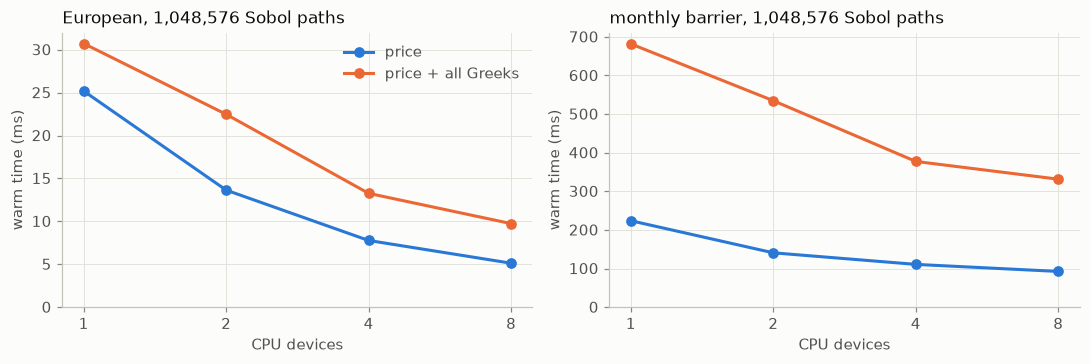

| 产品 | 模式 | 1 个设备 (ms) | 2 个设备 (ms) | 4 个设备 (ms) | 8 个设备 (ms) |
|:---|---:|---:|---:|---:|---:|
| European | price | 25.2 | 13.6 | 7.8 | 5.1 |
| European | price + Greeks | 30.7 | 22.5 | 13.3 | 9.7 |
| monthly barrier | price | 223.9 | 140.7 | 110.8 | 92.5 |
| monthly barrier | price + Greeks | 681.8 | 534.7 | 377.4 | 331.5 |

In [3]:
counts = [n for n in (1, 2, 4, 8) if n <= len(all_devices)]
timings = {}
for name, product in [("European", european), ("monthly barrier", barrier)]:
    for greeks in (False, True):
        row = []
        for n in counts:
            engine = dj.MonteCarloEngine(product, model, dj.MonteCarloSettings(enable_aad=greeks, devices=all_devices[:n]))
            row.append(best_ms(lambda: engine.value(N_PATHS)))
        timings[name, greeks] = row

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, name in zip(axes, ["European", "monthly barrier"]):
    ax.plot(counts, timings[name, False], marker="o", color=BLUE, label="price")
    ax.plot(counts, timings[name, True], marker="o", color=ORANGE, label="price + all Greeks")
    ax.set_xscale("log", base=2)
    ax.set_xticks(counts, [str(n) for n in counts])
    ax.set_ylim(bottom=0)
    ax.set_xlabel("CPU devices")
    ax.set_ylabel("warm time (ms)")
    ax.set_title(f"{name}, {N_PATHS:,} Sobol paths")
axes[0].legend(loc="upper right")
fig.tight_layout()
plt.show()

show_table(["产品", "模式"] + [f"{n} 个设备 (ms)" for n in counts],
           [[name, "price + Greeks" if greeks else "price"] + [f"{t:.1f}" for t in row] for (name, greeks), row in timings.items()])

## 2. 并行方式

- `shard_map`：默认方案，每个设备的块号由 `axis_index` 推出，复制的参数在入口处一次性标记为 device-varying，反向传播里没有逐块的跨设备通信；
- `auto`：`jit` + `NamedSharding`，交给 GSPMD 切分；
- `pmap`：在 JAX 0.11 中已基于 `shard_map` 实现，只作对照；
- `none`：单设备，所有块在一个 `scan` 里。

四种方式的结果在浮点误差内相同。

In [4]:
rows = []
for strategy in ("shard_map", "auto", "pmap", "none"):
    engine = dj.MonteCarloEngine(european, model, dj.MonteCarloSettings(enable_aad=True, parallel=strategy))
    result = engine.value(N_PATHS)
    rows.append([strategy, f"{best_ms(lambda: engine.value(N_PATHS)):.1f}", f"{result['PV']:.15f}", f"{result['d_spot']:.15f}"])
show_table(["parallel", "价格 + Greeks (ms)", "PV", "d_spot"], rows)

| parallel | 价格 + Greeks (ms) | PV | d_spot |
|:---|---:|---:|---:|
| shard_map | 10.4 | 5.201768833210827 | 0.335031449368459 |
| auto | 27.3 | 5.201768833210827 | 0.335031449368459 |
| pmap | 11.2 | 5.201768833210827 | 0.335031449368459 |
| none | 31.6 | 5.201768833210826 | 0.335031449368459 |

## 3. 确定性规约

默认模式下，各设备先加总自己的块，再做 `psum`。设备数不同，加法的顺序就不同，结果可能在最后几位不一样。
`deterministic_reduction=True` 先收集每个块的部分和与梯度，再严格按块号顺序相加，所以 PV 和梯度与设备数**逐位一致**，对应 DAL 的"thread-count bitwise invariant"。
代价是梯度要按块单独保存，而且只支持反向模式（`grad` / `jacrev`）。

In [5]:
rows, deterministic_results = [], []
for n in counts:
    for deterministic in (False, True):
        settings = dj.MonteCarloSettings(enable_aad=True, devices=all_devices[:n], deterministic_reduction=deterministic)
        result = dj.MonteCarloEngine(barrier, model, settings).value(2**18)
        if deterministic:
            deterministic_results.append(result)
        rows.append([n, "deterministic" if deterministic else "default", result["PV"].hex(), result["d_BARRIER"].hex()])
show_table(["设备数", "规约方式", "PV（十六进制）", "d_BARRIER（十六进制）"], rows)
print("deterministic results identical across device counts:", all(r == deterministic_results[0] for r in deterministic_results))

| 设备数 | 规约方式 | PV（十六进制） | d_BARRIER（十六进制） |
|:---|---:|---:|---:|
| 1 | default | 0x1.81d619caa4d74p+0 | 0x1.5a2cc94ef6048p-4 |
| 1 | deterministic | 0x1.81d619caa4d74p+0 | 0x1.5a2cc94ef6047p-4 |
| 2 | default | 0x1.81d619caa4d74p+0 | 0x1.5a2cc94ef6048p-4 |
| 2 | deterministic | 0x1.81d619caa4d74p+0 | 0x1.5a2cc94ef6047p-4 |
| 4 | default | 0x1.81d619caa4d73p+0 | 0x1.5a2cc94ef6048p-4 |
| 4 | deterministic | 0x1.81d619caa4d74p+0 | 0x1.5a2cc94ef6047p-4 |
| 8 | default | 0x1.81d619caa4d73p+0 | 0x1.5a2cc94ef6048p-4 |
| 8 | deterministic | 0x1.81d619caa4d74p+0 | 0x1.5a2cc94ef6047p-4 |

deterministic results identical across device counts: True


## 4. `float32` 路径

`dtype="float32"` 把随机数之后的路径数组（模型状态、路径、payoff）转成 float32，块内求和用 float32，块间累加仍用 float64；
随机数生成和逆正态变换保持 float64，以免均匀数被舍入成 1。消费级 GPU 的 FP64 吞吐很低，这个选项主要是为 GPU 准备的；在 CPU 上收益有限。

In [6]:
rows = []
for name, product in [("European", european), ("monthly barrier", barrier)]:
    results, times = {}, {}
    for dtype in ("float64", "float32"):
        engine = dj.MonteCarloEngine(product, model, dj.MonteCarloSettings(enable_aad=True, dtype=dtype))
        results[dtype] = engine.value(N_PATHS)
        times[dtype] = best_ms(lambda: engine.value(N_PATHS), repeat=3)
    diffs = {k: abs(results["float32"][k] / results["float64"][k] - 1) for k in results["float64"]}
    worst = max(diffs, key=diffs.get)
    rows.append([name, f"{diffs['PV']:.1e}", f"{diffs[worst]:.1e}（{worst}）", f"{times['float64']:.1f}", f"{times['float32']:.1f}"])
show_table(["产品", "PV 相对差异", "Greeks 中最大的相对差异", "float64 (ms)", "float32 (ms)"], rows)

| 产品 | PV 相对差异 | Greeks 中最大的相对差异 | float64 (ms) | float32 (ms) |
|:---|---:|---:|---:|---:|
| European | 3.7e-07 | 3.5e-06（d_rate） | 8.9 | 10.6 |
| monthly barrier | 4.5e-07 | 5.2e-03（d_vol） | 347.1 | 363.9 |

PV 在 float32 下只差 1e-6 量级。障碍期权的 Greeks 差得多一些：fuzzy 导数只来自贴近障碍的少数路径，float32 的舍入会改变哪些路径落在平滑带里。

## 5. 块数分桶

块数是编译时的静态形状。默认情况下块数会向上取到设备数的倍数（这里是 8），所以路径数的小幅变化不一定触发重新编译，但跨过这个边界就会。
`block_bucketing=True` 固定块大小、把块数向上取到 2 的幂，并用掩码屏蔽多出的路径，于是路径数在同一个桶里变化时直接复用编译结果，代价是多算一些被屏蔽的路径。
另外，`dj.config.configure(compilation_cache_dir=...)` 可以打开 JAX 的持久化编译缓存，跨进程复用。

In [7]:
rows = []
plain = dj.MonteCarloEngine(barrier, model, dj.MonteCarloSettings(enable_aad=True))
bucketed = dj.MonteCarloEngine(barrier, model, dj.MonteCarloSettings(enable_aad=True, block_bucketing=True))
for n in (300_000, 350_000, 400_000, 450_000, 500_000):
    timed = {}
    for label, engine in (("plain", plain), ("bucketed", bucketed)):
        start = time.perf_counter()
        pv = engine.value(n)["PV"]
        timed[label] = (1e3 * (time.perf_counter() - start), pv)
    rows.append([f"{n:,}", plain.layout(n).n_blocks, f"{timed['plain'][0]:.0f}", bucketed.layout(n).n_blocks, f"{timed['bucketed'][0]:.0f}",
                 f"{abs(timed['plain'][1] - timed['bucketed'][1]):.1e}"])
show_table(["路径数", "块数（不分桶）", "首次调用 (ms)", "块数（分桶）", "首次调用 (ms)", "两者 PV 差异"], rows)

| 路径数 | 块数（不分桶） | 首次调用 (ms) | 块数（分桶） | 首次调用 (ms) | 两者 PV 差异 |
|:---|---:|---:|---:|---:|---:|
| 300,000 | 40 | 2251 | 64 | 2157 | 0.0e+00 |
| 350,000 | 48 | 2441 | 64 | 193 | 4.4e-16 |
| 400,000 | 56 | 2284 | 64 | 196 | 2.2e-16 |
| 450,000 | 56 | 173 | 64 | 181 | 0.0e+00 |
| 500,000 | 64 | 2464 | 64 | 186 | 0.0e+00 |

不分桶时，块数每变一次（40、48、56、64）就要重新编译一次，只有 45 万和 40 万条路径恰好落在同一个块数上；分桶后块数都是 64，只编译一次。
两者处理的是同一批路径，PV 只差求和顺序带来的末位误差。

## 6. GPU：同一份代码

安装带 CUDA 的 jaxlib（`pip install -e ".[cuda12]"`）后，只需要换 `platform`。GPU 上可以考虑 `dtype="float32"` 和更大的 `block_size`。

In [8]:
try:
    gpus = dj.config.devices("gpu")
except RuntimeError:
    gpus = ()

if gpus:
    for dtype in ("float64", "float32"):
        engine = dj.MonteCarloEngine(european, model, dj.MonteCarloSettings(platform="gpu", enable_aad=True, dtype=dtype))
        print(dtype, engine.value(N_PATHS), f"{best_ms(lambda: engine.value(N_PATHS)):.1f} ms")
else:
    print("No GPU backend in this environment; install jax[cuda12] or jax[cuda13] to run this cell on a GPU.")

No GPU backend in this environment; install jax[cuda12] or jax[cuda13] to run this cell on a GPU.
